# AICE Associate 대비 실습 과정 — 7회차
## 인공신경망, 심층신경망, 딥러닝 프레임워크 (TensorFlow / Keras)

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **선수 학습**: 1~6회차. 6회차의 트리 앙상블 결과를 기준으로 신경망과 비교합니다.  
> **데이터**: 이진 분류 = **타이타닉** 생존, 다중 분류 = 타이타닉 **객실등급**, 회귀 = **캘리포니아 주택** 가격  
> **환경**: TensorFlow 2.x (Colab 기본 설치). 이 노트북의 코드는 Keras 2 (TF 2.15 이하) 와 Keras 3 (TF 2.16 이상) 에서 모두 동작합니다.

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| 1 | AI/ML/DL 개요, 데이터 획득하기 | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| 2 | 데이터 구조 확인하기, 기초 데이터 다루기 | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| 3 | 데이터 이해하기 (EDA) | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| 4 | 데이터 전처리하기 | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| 5 | AI 모델링 필수 개념, 지도학습 I | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| 6 | 지도학습 II | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| **7** | **인공신경망, 심층신경망, 딥러닝 프레임워크** | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| 8 | 비지도학습, 모델 성능 향상시키기 | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. 뉴런(퍼셉트론)이 입력을 받아 출력을 내는 과정을 `가중합 → 활성화 함수` 로 설명할 수 있다.
2. 은닉층이 왜 필요한지(XOR 문제)와 심층신경망(DNN)의 구조를 설명할 수 있다.
3. 출력층의 **활성화 함수와 손실 함수를 문제 유형(이진·다중 분류, 회귀)에 맞게** 고를 수 있다.
4. 경사하강법, epoch / batch_size, 옵티마이저, 학습률의 의미를 안다.
5. Keras `Sequential` 로 모델을 만들고 `compile → fit → evaluate → predict` 를 수행할 수 있다.
6. 학습 곡선으로 과적합을 진단하고 `Dropout`, `EarlyStopping`, `ModelCheckpoint` 로 대응할 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:10 | 0. 환경 준비, 데이터 준비 |
| 00:10 ~ 00:45 | 1. 인공신경망의 구성 요소 (뉴런, 활성화 함수, 은닉층) |
| 00:45 ~ 01:05 | 2. 신경망이 학습하는 방법 (손실, 경사하강법, epoch·batch) |
| 01:05 ~ 01:15 | 휴식 |
| 01:15 ~ 02:00 | 3. Keras 로 DNN 만들기 (이진 분류, 다중 분류, 회귀) |
| 02:00 ~ 02:30 | 4. 과적합 막기 (Dropout, EarlyStopping, ModelCheckpoint) |
| 02:30 ~ 02:40 | 휴식 |
| 02:40 ~ 03:00 | 5. 모델 비교, 6. 종합 실습, 정리 |

---
## 0. 환경 준비, 데이터 준비

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"        # TensorFlow 의 C++ 안내 메시지 숨기기 (import 전에 설정)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.get_logger().setLevel("ERROR")

# Mac(Apple Silicon)의 Metal GPU 플러그인은 작은 모델에서 느리고, 학습이 발산하는 수치 오류가 보고되어 있다.
# macOS 에서만 GPU 를 끄고 CPU 로 학습한다. (Colab·Windows·Linux 의 NVIDIA GPU 에는 영향 없음)
import platform
if platform.system() == "Darwin":
  tf.config.set_visible_devices([], "GPU")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_DIR = "data"
RANDOM_STATE = 42
print("TensorFlow", tf.__version__, "| 사용 GPU:", tf.config.get_visible_devices("GPU") or "없음 (CPU 사용)")

TensorFlow 2.15.0 | 사용 GPU: 없음 (CPU 사용)


In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
# ===== 실습 데이터: 캘리포니아 주택 가격(회귀), 타이타닉 생존(분류) =====
# data/ 폴더에 아래 파일이 있어야 합니다. (Colab 이면 왼쪽 파일 탭에서 data/ 폴더를 만들고 업로드)
#   california_housing_train.csv, california_housing_test.csv, titanic_train.csv, titanic_test.csv
# 원본 컬럼명은 영어라서 읽은 뒤 한글로 바꿉니다. (영어 = 한글 대응표는 아래 사전 참고)

HOUSING_COLS = {
  "longitude": "경도",                 # 서쪽일수록 작은 값 (-124 ~ -114)
  "latitude": "위도",                  # 북쪽일수록 큰 값 (32 ~ 42)
  "housing_median_age": "주택연식",    # 그 구역 주택 나이의 중앙값 (년)
  "total_rooms": "총방수",             # 구역 내 전체 방 수
  "total_bedrooms": "총침실수",        # 구역 내 전체 침실 수
  "population": "인구",                # 구역 인구
  "households": "가구수",              # 구역 가구 수
  "median_income": "소득중앙값",       # 가구 소득 중앙값 (단위: 만 달러)
  "median_house_value": "주택가격",    # 구역 주택 가격의 중앙값 (달러) <- 회귀 타깃
}
TITANIC_COLS = {
  "PassengerId": "승객ID",
  "Survived": "생존",                  # 1 = 생존, 0 = 사망 <- 분류 타깃
  "Pclass": "객실등급",                # 1등석 / 2등석 / 3등석
  "Name": "이름",
  "Sex": "성별",                       # male / female
  "Age": "나이",
  "SibSp": "동반형제배우자",           # 함께 탄 형제·배우자 수
  "Parch": "동반부모자녀",             # 함께 탄 부모·자녀 수
  "Ticket": "티켓번호",
  "Fare": "운임",                      # 지불한 요금 (파운드)
  "Cabin": "객실번호",
  "Embarked": "탑승항구",              # C = Cherbourg, Q = Queenstown, S = Southampton
}

for name in ["california_housing_train.csv", "california_housing_test.csv", "titanic_train.csv", "titanic_test.csv"]:
  if not os.path.exists(f"{DATA_DIR}/{name}"):
    raise FileNotFoundError(f"{DATA_DIR}/{name} 가 없습니다. data 폴더에 실습 파일을 넣어 주세요.")

housing = pd.read_csv(f"{DATA_DIR}/california_housing_train.csv").rename(columns=HOUSING_COLS)
housing_test = pd.read_csv(f"{DATA_DIR}/california_housing_test.csv").rename(columns=HOUSING_COLS)
titanic = pd.read_csv(f"{DATA_DIR}/titanic_train.csv").rename(columns=TITANIC_COLS)
titanic_test = pd.read_csv(f"{DATA_DIR}/titanic_test.csv").rename(columns=TITANIC_COLS)

print("housing:", housing.shape, "| housing_test:", housing_test.shape)
print("titanic:", titanic.shape, "| titanic_test:", titanic_test.shape)

housing: (17000, 9) | housing_test: (3000, 9)
titanic: (891, 12) | titanic_test: (418, 11)


### 0.1 전처리: 신경망은 스케일링이 **필수**

6회차 트리 모델과 달리 신경망은 입력값에 가중치를 곱해 더하는 계산을 수천 번 반복합니다. 컬럼마다 크기가 다르면(운임 0~512, 성별 0/1) 큰 값의 컬럼이 학습을 지배하고 학습이 불안정해집니다. 그래서 **StandardScaler 를 반드시** 적용합니다.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def preprocess_titanic(df: pd.DataFrame) -> pd.DataFrame:
  '''타이타닉 전처리 (5·6회차와 동일한 규칙)'''
  out = df.drop(columns=["승객ID", "이름", "티켓번호", "객실번호"])
  out["나이"] = out["나이"].fillna(out["나이"].median())
  out["탑승항구"] = out["탑승항구"].fillna(out["탑승항구"].mode()[0])
  out["가족수"] = out["동반형제배우자"] + out["동반부모자녀"] + 1
  out["혼자탑승"] = (out["가족수"] == 1).astype(int)
  out["성별"] = out["성별"].map({"male": 0, "female": 1})
  return pd.get_dummies(out, columns=["탑승항구"], drop_first=True, dtype=int)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
  '''주택 파생 변수 (5·6회차와 동일)'''
  out = df.copy()
  out["가구당방수"] = out["총방수"] / out["가구수"]
  out["침실비율"] = out["총침실수"] / out["총방수"]
  out["가구당인구"] = out["인구"] / out["가구수"]
  return out


# 이진 분류: 타이타닉 생존 (6회차와 같은 분할)
titanic_clean = preprocess_titanic(titanic)
Xc = titanic_clean.drop(columns=["생존"])
yc = titanic_clean["생존"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)
sc_c = StandardScaler()
Xc_train_s = sc_c.fit_transform(Xc_train).astype("float32")     # 신경망 입력은 float32 가 기본
Xc_test_s = sc_c.transform(Xc_test).astype("float32")

# 회귀: 캘리포니아 주택 (6회차와 같은 분할)
housing_fe = add_features(housing)
Xr = housing_fe.drop(columns=["주택가격"])
yr = housing_fe["주택가격"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)
sc_r = StandardScaler()
Xr_train_s = sc_r.fit_transform(Xr_train).astype("float32")
Xr_test_s = sc_r.transform(Xr_test).astype("float32")

print("이진 분류:", Xc_train_s.shape, Xc_test_s.shape)
print("회귀     :", Xr_train_s.shape, Xr_test_s.shape)

이진 분류: (712, 10) (179, 10)
회귀     : (13600, 11) (3400, 11)


---
## 1. 인공신경망의 구성 요소

### 1.1 뉴런 (퍼셉트론)

#### 한 줄 정의
입력마다 **가중치를 곱해 더하고(가중합), 편향을 더한 뒤, 활성화 함수에 통과시켜** 출력을 내는 계산 단위.

#### 직관적 설명
뇌의 신경세포를 흉내 낸 것입니다. 여러 신호(입력)를 받아 각 신호의 **중요도(가중치)** 만큼 반영해 합치고, 그 합이 충분히 크면 다음으로 신호를 보냅니다(활성화).

```
 입력        가중치
 x1 ──── w1 ──┐
 x2 ──── w2 ──┼──▶ z = w1·x1 + w2·x2 + w3·x3 + b ──▶ 활성화 함수 f(z) ──▶ 출력
 x3 ──── w3 ──┘                          ↑ 편향(bias)
```

5회차의 **로지스틱 회귀는 뉴런 1개** 와 같습니다. 가중합 z 를 시그모이드에 넣어 확률을 냈습니다. 신경망은 이런 뉴런을 **여러 개, 여러 층** 으로 쌓은 것입니다.

In [5]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))


# 승객 한 명: [성별(여=1), 객실등급, 나이(스케일링 전 그대로 예시)]
x = np.array([1.0, 1.0, 29.0])
w = np.array([2.5, -0.9, -0.03])        # 사람이 임의로 정한 가중치 (학습하면 모델이 찾는다)
b = 0.5

z = np.dot(w, x) + b                     # 가중합
p = sigmoid(z)                           # 활성화
print(f"가중합 z = {w[0]}×{x[0]} + {w[1]}×{x[1]} + {w[2]}×{x[2]} + {b} = {z:.3f}")
print(f"시그모이드(z) = {p:.3f}  -> 생존 확률로 해석")

가중합 z = 2.5×1.0 + -0.9×1.0 + -0.03×29.0 + 0.5 = 1.230
시그모이드(z) = 0.774  -> 생존 확률로 해석


### 1.2 활성화 함수

활성화 함수가 없으면 층을 아무리 쌓아도 결국 **직선 하나(선형 모델)** 와 같아집니다. 가중합의 가중합은 여전히 가중합이기 때문입니다. 활성화 함수가 **꺾임(비선형성)** 을 넣어 줘야 복잡한 패턴을 배울 수 있습니다.

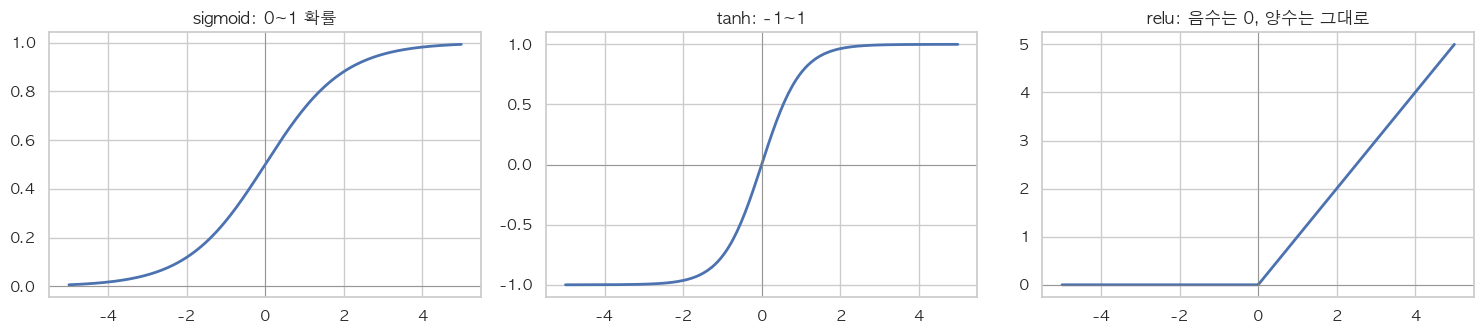

softmax 입력 : [2.  1.  0.1] -> 출력: [0.659 0.242 0.099] | 합: 1.0


In [6]:
z = np.linspace(-5, 5, 200)
funcs = {
  "sigmoid: 0~1 확률": sigmoid(z),
  "tanh: -1~1": np.tanh(z),
  "relu: 음수는 0, 양수는 그대로": np.maximum(0, z),
}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (name, val) in zip(axes, funcs.items()):
  ax.plot(z, val, linewidth=2)
  ax.axhline(0, color="gray", linewidth=0.5)
  ax.axvline(0, color="gray", linewidth=0.5)
  ax.set_title(name)
plt.tight_layout()
plt.show()

# softmax: 여러 출력 값을 '합이 1 인 확률' 로 바꾼다 (다중 분류 출력층)
scores = np.array([2.0, 1.0, 0.1])
softmax = np.exp(scores) / np.exp(scores).sum()
print("softmax 입력 :", scores, "-> 출력:", softmax.round(3), "| 합:", softmax.sum().round(3))

| 활성화 함수 | 출력 범위 | 어디에 쓰나 |
|------|:---:|------|
| **relu** | 0 ~ ∞ | **은닉층의 기본값.** 계산이 빠르고 깊은 신경망도 잘 학습됨 |
| **sigmoid** | 0 ~ 1 | **이진 분류의 출력층** (생존 확률) |
| **softmax** | 0 ~ 1, 합 = 1 | **다중 분류의 출력층** (1·2·3등석 각각의 확률) |
| 없음 (`linear`) | -∞ ~ ∞ | **회귀의 출력층** (가격 같은 숫자 그대로) |
| tanh | -1 ~ 1 | 은닉층 (relu 이전에 많이 썼음, RNN 등) |

### 1.3 은닉층이 필요한 이유: XOR 문제

뉴런 1개(= 로지스틱 회귀)는 **직선 하나** 로만 데이터를 나눕니다. 아래 XOR 데이터는 어떤 직선으로도 나눌 수 없습니다. 입력과 출력 사이에 **은닉층(hidden layer)** 을 넣으면 해결됩니다.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# XOR: 두 입력이 서로 다르면 1, 같으면 0
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

single = LogisticRegression().fit(X_xor, y_xor)
mlp = MLPClassifier(hidden_layer_sizes=(4,), activation="tanh", solver="lbfgs", random_state=1, max_iter=1000).fit(X_xor, y_xor)

print("입력       :", X_xor.tolist())
print("정답       :", y_xor.tolist())
print("뉴런 1개   :", single.predict(X_xor).tolist(), "정확도", single.score(X_xor, y_xor))
print("은닉층 포함:", mlp.predict(X_xor).tolist(), "정확도", mlp.score(X_xor, y_xor))

입력       : [[0, 0], [0, 1], [1, 0], [1, 1]]
정답       : [0, 1, 1, 0]
뉴런 1개   : [0, 0, 0, 0] 정확도 0.5
은닉층 포함: [0, 1, 1, 0] 정확도 1.0


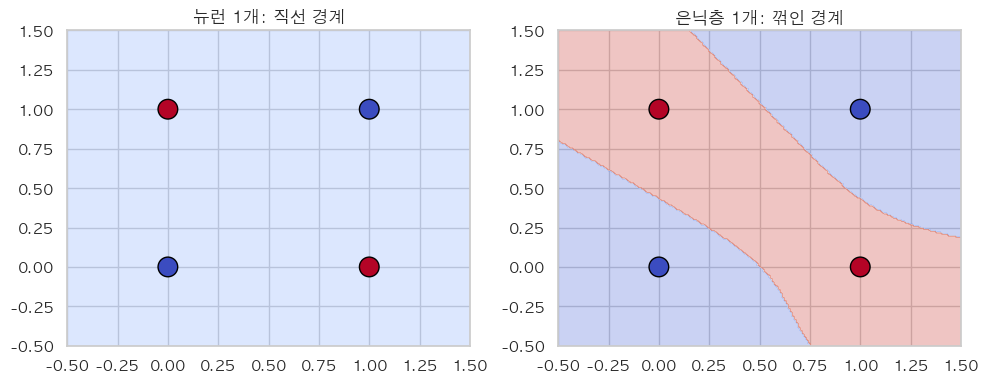

In [8]:
gx, gy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[gx.ravel(), gy.ravel()]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, m) in zip(axes, [("뉴런 1개: 직선 경계", single), ("은닉층 1개: 꺾인 경계", mlp)]):
  ax.contourf(gx, gy, m.predict(grid).reshape(gx.shape), alpha=0.3, cmap="coolwarm")
  ax.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="coolwarm", s=200, edgecolor="black")
  ax.set_title(name)
plt.tight_layout()
plt.show()

### 1.4 심층신경망 (DNN, Deep Neural Network)

은닉층이 **2개 이상** 이면 "깊다(deep)" 고 하고, 그런 신경망을 쓰는 것을 **딥러닝** 이라고 합니다. 각 층의 모든 뉴런이 다음 층의 모든 뉴런과 연결된 층을 **완전연결층(Dense, Fully Connected)** 이라고 합니다.

```
입력층          은닉층 1        은닉층 2       출력층
(특징 10개)     (뉴런 32개)     (뉴런 16개)    (뉴런 1개)
  ○ ─────┐       ○              ○
  ○ ─────┼─────▶ ○ ───────────▶ ○ ──────────▶ ○  → 생존 확률
  ...    │       ...            ...
  ○ ─────┘       ○              ○
             relu            relu          sigmoid
```

| 용어 | 뜻 |
|------|------|
| 입력층 | 특징(컬럼) 수만큼의 입력. 계산은 하지 않음 |
| 은닉층 | 입력과 출력 사이의 층. 층 수와 뉴런 수는 **사람이 정하는 하이퍼파라미터** |
| 출력층 | 문제 유형에 맞는 뉴런 수와 활성화 함수 |
| 파라미터 | 가중치 + 편향. Dense 층 하나의 파라미터 수 = **입력 수 × 뉴런 수 + 뉴런 수** |

---
## 2. 신경망이 학습하는 방법

### 2.1 손실 함수: "얼마나 틀렸나" 를 숫자로

학습의 목표는 **손실(loss)을 가장 작게 만드는 가중치** 를 찾는 것입니다. 문제 유형마다 손실 함수가 정해져 있습니다.

| 문제 | 출력층 | 손실 함수 (`loss=`) | 정답 y 형태 |
|------|------|------|------|
| **이진 분류** | `Dense(1, activation="sigmoid")` | `"binary_crossentropy"` | 0 / 1 |
| **다중 분류** | `Dense(클래스 수, activation="softmax")` | `"sparse_categorical_crossentropy"` | 정수 0, 1, 2 … |
| 다중 분류 | `Dense(클래스 수, activation="softmax")` | `"categorical_crossentropy"` | 원-핫 [1,0,0] … (`to_categorical`) |
| **회귀** | `Dense(1)` (활성화 없음) | `"mse"` (또는 `"mae"`) | 숫자 |

> **시험 최다 출제 포인트** 가 이 표입니다. 출력층 활성화 함수와 손실 함수의 짝이 틀리면 학습이 되지 않거나 엉뚱한 결과가 나옵니다.

**크로스엔트로피** 는 "정답 클래스에 준 확률이 낮을수록 크게 벌주는" 손실입니다. 정답이 생존(1)인데 생존 확률을 0.9 로 냈으면 손실이 작고(0.105), 0.1 로 냈으면 손실이 큽니다(2.303).

In [9]:
for p in [0.9, 0.5, 0.1]:
  print(f"정답=1, 예측 확률 {p}: binary crossentropy = -log({p}) = {-np.log(p):.3f}")

정답=1, 예측 확률 0.9: binary crossentropy = -log(0.9) = 0.105
정답=1, 예측 확률 0.5: binary crossentropy = -log(0.5) = 0.693
정답=1, 예측 확률 0.1: binary crossentropy = -log(0.1) = 2.303


### 2.2 경사하강법: 손실을 줄이는 방향으로 조금씩

#### 직관적 설명
안개 낀 산에서 가장 낮은 골짜기를 찾는 상황입니다. 주변이 안 보이니 **발밑의 경사(기울기)** 만 보고, 내려가는 방향으로 **한 걸음씩** 이동합니다. 이 한 걸음의 크기가 **학습률(learning rate)** 입니다.

```
새 가중치 = 현재 가중치 - 학습률 × 기울기(손실을 가중치로 미분한 값)
```

신경망은 층이 많아서, 출력층의 오차를 **뒤에서 앞으로 거꾸로 전달** 하며 각 가중치의 기울기를 계산합니다. 이것을 **역전파(backpropagation)** 라고 합니다. Keras 가 자동으로 해 줍니다.

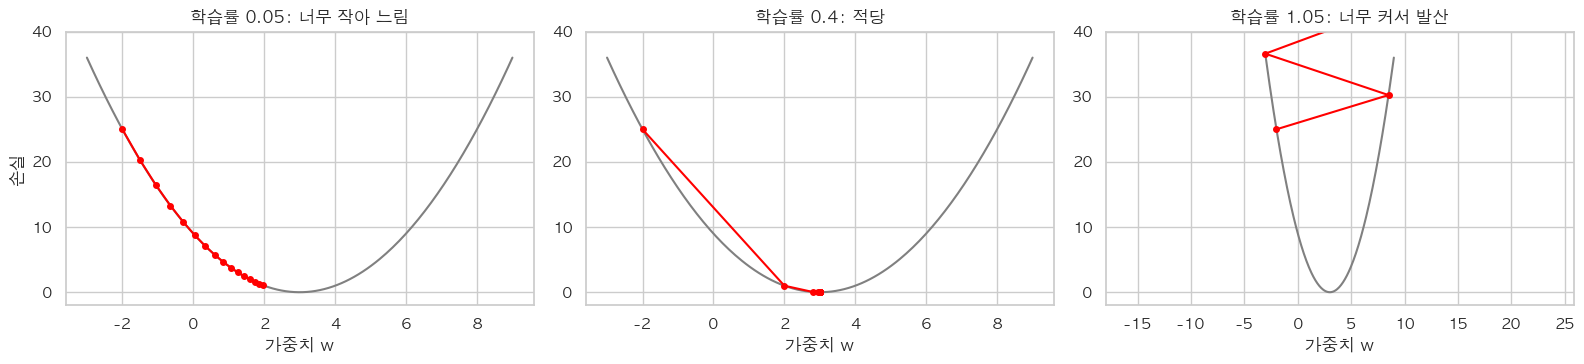

In [10]:
# 손실 = (w - 3)² 을 최소로 하는 w 찾기 (정답 w = 3). 학습률에 따라 어떻게 움직이나
def gradient_descent(lr: float, steps: int = 15, w0: float = -2.0) -> list[float]:
  path = [w0]
  for _ in range(steps):
    grad = 2 * (path[-1] - 3)          # 미분: d/dw (w-3)² = 2(w-3)
    path.append(path[-1] - lr * grad)
  return path


w_axis = np.linspace(-3, 9, 200)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, lr in zip(axes, [0.05, 0.4, 1.05]):
  path = np.array(gradient_descent(lr))
  ax.plot(w_axis, (w_axis - 3) ** 2, color="gray")
  ax.plot(path, (path - 3) ** 2, "o-", color="red", markersize=4)
  ax.set_ylim(-2, 40)
  ax.set_title({0.05: "학습률 0.05: 너무 작아 느림", 0.4: "학습률 0.4: 적당", 1.05: "학습률 1.05: 너무 커서 발산"}[lr])
  ax.set_xlabel("가중치 w")
axes[0].set_ylabel("손실")
plt.tight_layout()
plt.show()

### 2.3 epoch, batch_size, iteration

| 용어 | 뜻 | 예 (학습 데이터 712명, batch_size=32) |
|------|------|------|
| **batch_size** | 가중치를 한 번 고칠 때 보는 데이터 수 | 32명 |
| **iteration (step)** | 가중치를 고친 횟수 | 712 / 32 ≈ 23번이면 전체를 한 바퀴 |
| **epoch** | 학습 데이터 **전체를 한 바퀴** 본 횟수 | `epochs=50` 이면 23 × 50 = 1,150번 수정 |

- batch_size 가 **작으면**: 자주 고쳐서 빨리 배우지만 들쭉날쭉. **크면**: 안정적이지만 한 번에 느리고 메모리를 많이 씀. 보통 32 ~ 256.
- epoch 가 **적으면** 덜 배우고(과소적합), **많으면** 외웁니다(과적합). 4장의 EarlyStopping 이 알맞은 지점에서 자동으로 멈춰 줍니다.

### 2.4 옵티마이저

경사하강법을 개선한 "걸음 방식" 입니다. **특별한 이유가 없으면 `adam`** 을 씁니다.

| 옵티마이저 | 특징 |
|------|------|
| `sgd` | 기본 경사하강법. 학습률 조절이 까다로움 |
| `rmsprop` | 가중치마다 걸음 크기를 자동 조절 |
| **`adam`** | 관성 + 자동 조절. **가장 무난한 기본값** (기본 학습률 0.001) |

학습률을 바꾸려면 문자열 대신 객체로 넘깁니다: `optimizer=keras.optimizers.Adam(learning_rate=0.0005)`

### 📝 시험 출제 포인트 (1·2장)

- 이진 분류 출력층 `Dense(1, activation="sigmoid")` + `loss="binary_crossentropy"`
- 다중 분류 출력층 `Dense(k, activation="softmax")` + `loss="sparse_categorical_crossentropy"` (y 가 정수) 또는 `"categorical_crossentropy"` (y 가 원-핫)
- 회귀 출력층 `Dense(1)` + `loss="mse"`
- 은닉층은 `activation="relu"`
- 파라미터 수 계산: `입력 × 뉴런 + 뉴런`

### ⚠️ 자주 하는 실수 (1·2장)

- **이진 분류에 softmax 1개**: softmax 는 합이 1 이라 출력이 1개면 항상 1.0 입니다. 이진은 sigmoid.
- **회귀 출력층에 relu/sigmoid**: sigmoid 는 0~1 만 내므로 가격을 예측할 수 없습니다. 회귀 출력층은 활성화 없음.
- **y 형태와 손실 불일치**: 정수 y 에 `categorical_crossentropy` 를 쓰면 shape 오류가 납니다. 정수면 `sparse_` 를 붙입니다.

---
## 3. Keras 로 DNN 만들기

### Keras 모델링 5단계

```python
model = keras.Sequential([...])                      # ① 구조 정의: 층을 순서대로 쌓기
model.compile(optimizer=..., loss=..., metrics=[...])  # ② 학습 방법 정하기
history = model.fit(X_train, y_train, epochs=..., batch_size=..., validation_split=...)  # ③ 학습
model.evaluate(X_test, y_test)                       # ④ 평가
model.predict(X_new)                                 # ⑤ 예측
```

### 3.1 이진 분류: 타이타닉 생존

In [11]:
keras.utils.set_random_seed(RANDOM_STATE)      # 가중치 초기값·데이터 섞기를 고정 (재현성)

n_features = Xc_train_s.shape[1]
model_c = keras.Sequential([
  keras.Input(shape=(n_features,)),            # 입력: 특징 10개
  layers.Dense(32, activation="relu"),         # 은닉층 1
  layers.Dense(16, activation="relu"),         # 은닉층 2
  layers.Dense(1, activation="sigmoid"),       # 출력층: 생존 확률
])
model_c.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 32)                352       


 dense_1 (Dense)             (None, 16)                528       


 dense_2 (Dense)             (None, 1)                 17        


Total params: 897 (3.50 KB)


Trainable params: 897 (3.50 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


**파라미터 수 확인** (입력 × 뉴런 + 뉴런)

| 층 | 계산 | 파라미터 |
|------|------|:---:|
| 은닉층 1 | 10 × 32 + 32 | 352 |
| 은닉층 2 | 32 × 16 + 16 | 528 |
| 출력층 | 16 × 1 + 1 | 17 |
| **합계** | | **897** |

입력 특징은 10개입니다 (객실등급, 성별, 나이, 동반형제배우자, 동반부모자녀, 운임, 가족수, 혼자탑승, 탑승항구_Q, 탑승항구_S). 5회차 로지스틱 회귀의 파라미터는 11개(가중치 10 + 편향 1)였습니다. 신경망은 이 897개를 학습합니다.

In [12]:
model_c.compile(
  optimizer="adam",
  loss="binary_crossentropy",
  metrics=["accuracy"],
)

start = time.time()
history_c = model_c.fit(
  Xc_train_s, yc_train,
  epochs=50,
  batch_size=32,
  validation_split=0.2,        # 학습 데이터의 마지막 20% 를 검증용으로 떼어 매 epoch 평가
  verbose=0,                   # 0: 진행 막대 숨김 (수업 중엔 1 로 보면 좋다)
)
print(f"학습 시간 {time.time() - start:.1f}초 | 기록된 지표: {list(history_c.history.keys())}")

학습 시간 1.8초 | 기록된 지표: ['loss', 'accuracy', 'val_loss', 'val_accuracy']


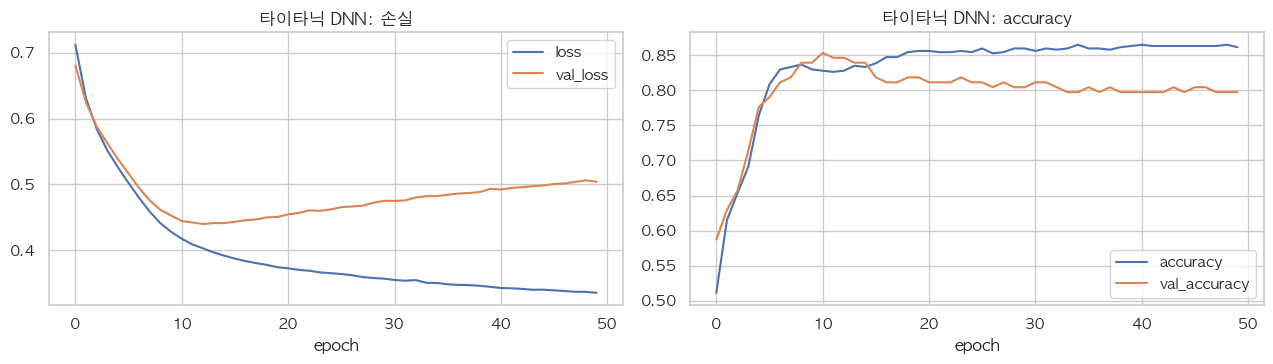

In [13]:
def plot_history(history, metric: str, title: str) -> None:
  '''학습 곡선: 손실과 지표를 train / validation 으로 나눠 그린다'''
  h = pd.DataFrame(history.history)
  fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
  h[["loss", "val_loss"]].plot(ax=axes[0], title=f"{title}: 손실")
  h[[metric, f"val_{metric}"]].plot(ax=axes[1], title=f"{title}: {metric}")
  for ax in axes:
    ax.set_xlabel("epoch")
  plt.tight_layout()
  plt.show()


plot_history(history_c, "accuracy", "타이타닉 DNN")

**학습 곡선 읽는 법**

| 모양 | 진단 |
|------|------|
| `loss`, `val_loss` 가 함께 내려감 | 잘 배우는 중 |
| `loss` 는 계속 내려가는데 `val_loss` 가 **다시 올라감** | **과적합 시작** → 그 지점에서 멈춰야 함 (4장) |
| 둘 다 높은 채로 평평 | 과소적합 → 층·뉴런·epoch 늘리기 |

In [14]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

loss, acc = model_c.evaluate(Xc_test_s, yc_test, verbose=0)
print(f"test 손실 {loss:.4f} | test 정확도 {acc:.4f}")

proba_c = model_c.predict(Xc_test_s, verbose=0).ravel()    # (179, 1) -> (179,) 생존 확률
pred_c = (proba_c >= 0.5).astype(int)                        # 확률 -> 0/1 (predict 는 확률을 돌려준다!)
print("확률 5개:", proba_c[:5].round(3), "-> 예측:", pred_c[:5])
print(f"F1 {f1_score(yc_test, pred_c):.4f} | AUC {roc_auc_score(yc_test, proba_c):.4f}")
print("혼동행렬:\n", confusion_matrix(yc_test, pred_c))

test 손실 0.4547 | test 정확도 0.8101
확률 5개: [0.104 0.013 0.186 0.045 0.792] -> 예측: [0 0 0 0 1]
F1 0.7119 | AUC 0.8494
혼동행렬:
 [[103   7]
 [ 27  42]]


> **주의**: Keras 의 `predict` 는 scikit-learn 과 달리 **클래스가 아니라 확률** 을 돌려줍니다. 이진 분류는 `>= 0.5` 로, 다중 분류는 `argmax` 로 클래스를 직접 만들어야 합니다.

### 3.2 다중 분류: 객실등급 예측 (1·2·3등석)

같은 타이타닉 데이터로 "운임·나이·가족 정보 등으로 **몇 등석 승객인지** 맞히기" 를 해 봅니다. 클래스가 3개이므로 출력층은 **뉴런 3개 + softmax** 입니다.

In [15]:
Xm = titanic_clean.drop(columns=["객실등급", "생존"])
ym = titanic_clean["객실등급"] - 1          # 1·2·3 -> 0·1·2 (Keras 의 정수 라벨은 0 부터 시작해야 한다)
print("클래스 분포:", ym.value_counts().sort_index().to_dict())

Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.2, random_state=RANDOM_STATE, stratify=ym)
sc_m = StandardScaler()
Xm_train_s = sc_m.fit_transform(Xm_train).astype("float32")
Xm_test_s = sc_m.transform(Xm_test).astype("float32")

keras.utils.set_random_seed(RANDOM_STATE)
model_m = keras.Sequential([
  keras.Input(shape=(Xm_train_s.shape[1],)),
  layers.Dense(32, activation="relu"),
  layers.Dense(16, activation="relu"),
  layers.Dense(3, activation="softmax"),     # 클래스 3개 -> 뉴런 3개, 합이 1 인 확률
])
model_m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_m = model_m.fit(Xm_train_s, ym_train, epochs=60, batch_size=32, validation_split=0.2, verbose=0)

proba_m = model_m.predict(Xm_test_s, verbose=0)
print("확률 예시(첫 3명):\n", proba_m[:3].round(3), "\n각 행의 합:", proba_m[:3].sum(axis=1).round(3))
pred_m = proba_m.argmax(axis=1)             # 가장 큰 확률의 위치 = 예측 클래스
print("test 정확도:", round(accuracy_score(ym_test, pred_m), 4))
print("혼동행렬 (행: 실제 1·2·3등석):\n", confusion_matrix(ym_test, pred_m))

클래스 분포: {0: 216, 1: 184, 2: 491}


확률 예시(첫 3명):
 [[0.008 0.394 0.598]
 [0.962 0.037 0.   ]
 [0.514 0.378 0.107]] 
각 행의 합: [1. 1. 1.]
test 정확도: 0.8547
혼동행렬 (행: 실제 1·2·3등석):
 [[40  1  2]
 [ 1 22 14]
 [ 2  6 91]]


In [16]:
# 같은 문제를 원-핫 라벨 + categorical_crossentropy 로: 결과는 같고 y 의 형태만 다르다
ym_train_oh = keras.utils.to_categorical(ym_train, num_classes=3)
print("정수 라벨:", ym_train.values[:3], "-> 원-핫:\n", ym_train_oh[:3])

keras.utils.set_random_seed(RANDOM_STATE)
model_m2 = keras.Sequential([
  keras.Input(shape=(Xm_train_s.shape[1],)),
  layers.Dense(32, activation="relu"),
  layers.Dense(16, activation="relu"),
  layers.Dense(3, activation="softmax"),
])
model_m2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_m2.fit(Xm_train_s, ym_train_oh, epochs=60, batch_size=32, validation_split=0.2, verbose=0)
print("원-핫 방식 test 정확도:", round(accuracy_score(ym_test, model_m2.predict(Xm_test_s, verbose=0).argmax(axis=1)), 4))

정수 라벨: [0 1 2] -> 원-핫:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


원-핫 방식 test 정확도: 0.8547


### 3.3 회귀: 캘리포니아 주택 가격

회귀 신경망에서는 **목표값의 크기** 도 신경 써야 합니다. 주택가격은 수십만 달러라서, 그대로 두면 출력층이 그 큰 숫자를 만들어 내기까지 아주 오래 걸리고 손실값도 수백억 단위가 됩니다. **10만 달러 단위로 나눠서** 학습하고, 평가할 때 다시 곱합니다.

학습 시간 3.3초 | 실제 학습한 epoch: 60


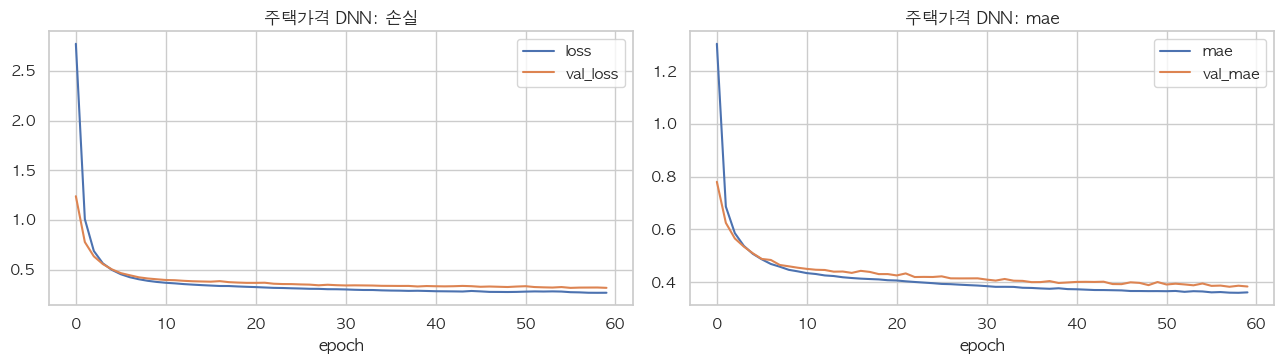

In [17]:
SCALE_Y = 100_000
yr_train_s = (yr_train / SCALE_Y).astype("float32")        # 예: 452,600 달러 -> 4.526

keras.utils.set_random_seed(RANDOM_STATE)
model_r = keras.Sequential([
  keras.Input(shape=(Xr_train_s.shape[1],)),
  layers.Dense(64, activation="relu"),
  layers.Dense(32, activation="relu"),
  layers.Dense(1),                                           # 회귀: 활성화 함수 없음
])
model_r.compile(optimizer="adam", loss="mse", metrics=["mae"])

start = time.time()
history_r = model_r.fit(
  Xr_train_s, yr_train_s, epochs=60, batch_size=256, validation_split=0.2, verbose=0,
  callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
)
print(f"학습 시간 {time.time() - start:.1f}초 | 실제 학습한 epoch: {len(history_r.history['loss'])}")
plot_history(history_r, "mae", "주택가격 DNN")

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

pred_r = model_r.predict(Xr_test_s, verbose=0).ravel() * SCALE_Y     # 10만 달러 단위 -> 달러
print(f"test RMSE {np.sqrt(mean_squared_error(yr_test, pred_r)):,.0f} 달러 | test R² {r2_score(yr_test, pred_r):.4f}")

test RMSE 54,375 달러 | test R² 0.7854


### 📝 시험 출제 포인트 (3장)

- "`Sequential` 로 은닉층 2개(relu)와 출력층을 가진 모델을 만드시오" → 위 구조 그대로
- "`model.summary()` 로 구조 확인" / "총 파라미터 수는?"
- `compile(optimizer="adam", loss=..., metrics=["accuracy"])`
- `fit(X, y, epochs=, batch_size=, validation_split=0.2)` 또는 `validation_data=(X_val, y_val)`
- `history.history["val_loss"]` 로 학습 곡선 그리기
- `evaluate` 는 `[손실, 지표]` 리스트를 돌려준다

### ⚠️ 자주 하는 실수 (3장)

- **스케일링 생략**: 신경망은 트리와 달리 스케일링이 없으면 학습이 크게 나빠집니다.
- **`predict` 결과를 그대로 정확도 계산에 사용**: 확률이므로 0.5 기준(이진)이나 `argmax`(다중)로 바꿔야 합니다.
- **다중 분류 라벨이 1 부터 시작**: `sparse_categorical_crossentropy` 는 0 부터 시작하는 정수를 기대합니다. 1·2·3 이면 1 을 빼세요.
- **`input_shape` 에 행 수까지 넣음**: `keras.Input(shape=(특징 수,))` 입니다. 행 수(샘플 수)는 넣지 않습니다. 쉼표 하나 `(11,)` 에 주의.

---
## 4. 과적합 막기

신경망은 파라미터가 많아서 작은 데이터(타이타닉 712명)를 금방 외웁니다. 일부러 **큰 모델을 오래** 학습시켜 과적합을 만들고, 세 가지 도구로 막아 봅니다.

| 도구 | 하는 일 | 코드 |
|------|------|------|
| **Dropout** | 학습할 때마다 뉴런 일부를 **무작위로 꺼서** 특정 뉴런에 의존하지 않게 함 | `layers.Dropout(0.3)` (30% 끔) |
| **EarlyStopping** | `val_loss` 가 더 나아지지 않으면 **학습을 자동 중단** | `callbacks.EarlyStopping(patience=10, restore_best_weights=True)` |
| **ModelCheckpoint** | 학습 중 **가장 좋았던 순간의 모델을 파일로 저장** | `callbacks.ModelCheckpoint("best.keras", save_best_only=True)` |
| L2 규제 | 가중치가 커지지 않게 벌점 | `layers.Dense(64, kernel_regularizer=keras.regularizers.l2(0.001))` |
| BatchNormalization | 층 사이 값의 분포를 정돈해 학습 안정화 | `layers.BatchNormalization()` |

과적합 실험 학습 시간 5.3초, 파라미터 34,561개


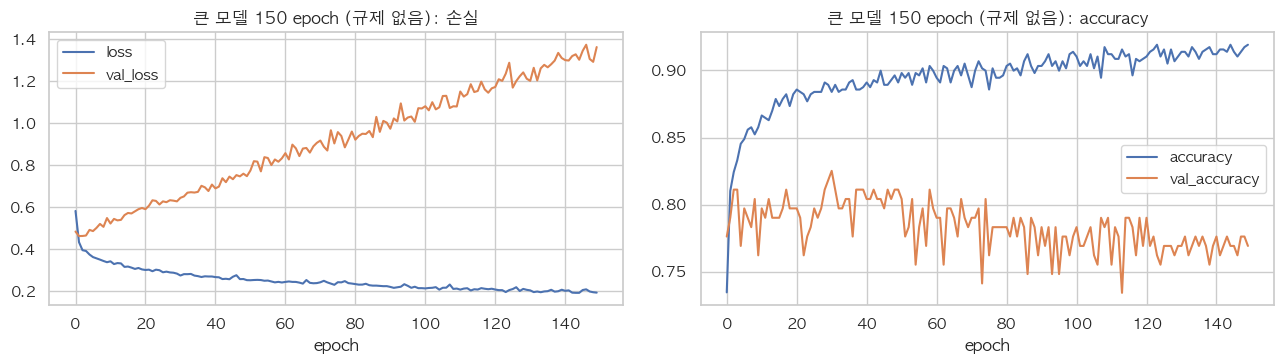

In [19]:
def build_big(dropout: float = 0.0) -> keras.Model:
  '''일부러 큰 모델: 은닉층 3개 x 뉴런 128개. dropout > 0 이면 각 은닉층 뒤에 Dropout'''
  model = keras.Sequential([keras.Input(shape=(n_features,))])
  for _ in range(3):
    model.add(layers.Dense(128, activation="relu"))
    if dropout > 0:
      model.add(layers.Dropout(dropout))
  model.add(layers.Dense(1, activation="sigmoid"))
  model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
  return model


keras.utils.set_random_seed(RANDOM_STATE)
big = build_big(dropout=0.0)
start = time.time()
h_big = big.fit(Xc_train_s, yc_train, epochs=150, batch_size=32, validation_split=0.2, verbose=0)
print(f"과적합 실험 학습 시간 {time.time() - start:.1f}초, 파라미터 {big.count_params():,}개")
plot_history(h_big, "accuracy", "큰 모델 150 epoch (규제 없음)")

`loss` 는 epoch 가 갈수록 계속 내려가는데 `val_loss` 는 초반 이후 **다시 올라갑니다.** 두 선이 벌어지는 것이 학습 데이터를 외워 버린 전형적인 과적합입니다.

150 epoch 중 19 epoch 에서 자동 중단 | val_loss 최저 epoch: 4


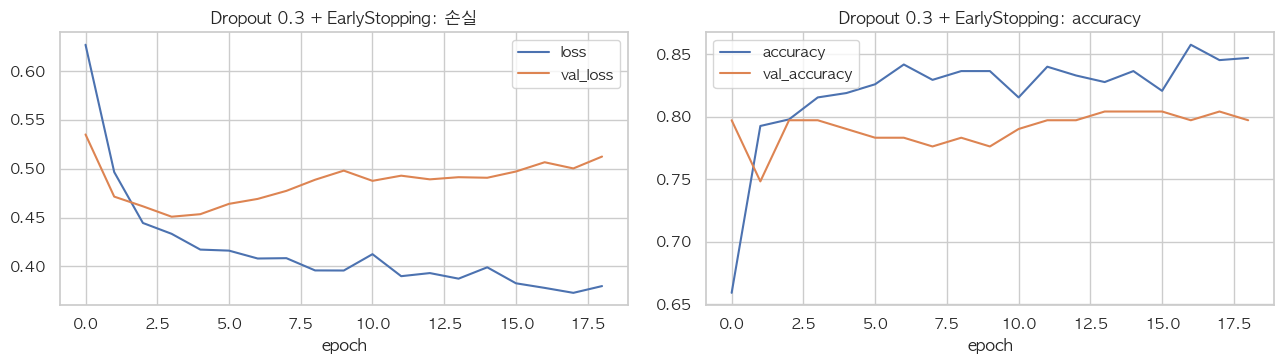

In [20]:
CKPT_PATH = f"{DATA_DIR}/titanic_best.keras"

keras.utils.set_random_seed(RANDOM_STATE)
regularized = build_big(dropout=0.3)
callbacks = [
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
  keras.callbacks.ModelCheckpoint(CKPT_PATH, monitor="val_loss", save_best_only=True),
]
h_reg = regularized.fit(Xc_train_s, yc_train, epochs=150, batch_size=32, validation_split=0.2,
                        callbacks=callbacks, verbose=0)
stopped = len(h_reg.history["loss"])
best_epoch = int(np.argmin(h_reg.history["val_loss"])) + 1
print(f"150 epoch 중 {stopped} epoch 에서 자동 중단 | val_loss 최저 epoch: {best_epoch}")
plot_history(h_reg, "accuracy", "Dropout 0.3 + EarlyStopping")

In [21]:
rows = []
for name, m in [("큰 모델 (규제 없음)", big), ("Dropout + EarlyStopping", regularized)]:
  tr_loss, tr_acc = m.evaluate(Xc_train_s, yc_train, verbose=0)
  te_loss, te_acc = m.evaluate(Xc_test_s, yc_test, verbose=0)
  rows.append({"모델": name, "train 정확도": round(tr_acc, 4), "test 정확도": round(te_acc, 4),
               "train 손실": round(tr_loss, 4), "test 손실": round(te_loss, 4)})
pd.DataFrame(rows).set_index("모델")

,train 정확도,test 정확도,train 손실,test 손실
모델,,,,
큰 모델 (규제 없음),0.8919,0.7821,0.4163,1.2076
Dropout + EarlyStopping,0.8174,0.7989,0.4072,0.4374


규제를 넣은 모델은 train 정확도가 낮아졌지만 **test 손실이 크게 줄었습니다.** 손실이 작다는 것은 확률을 덜 엉뚱하게(자신만만하게 틀리지 않게) 낸다는 뜻입니다.

> `restore_best_weights=True` 가 없으면 EarlyStopping 은 **멈춘 시점** 의 가중치를 남깁니다. 멈춘 시점은 최고 시점보다 `patience` 만큼 뒤라 이미 조금 과적합된 상태입니다. 꼭 `True` 로 둡니다.

### 4.1 모델 저장과 불러오기

In [22]:
loaded = keras.models.load_model(CKPT_PATH)          # ModelCheckpoint 가 저장한 최고 시점의 모델
print("불러온 모델 test 정확도:", round(loaded.evaluate(Xc_test_s, yc_test, verbose=0)[1], 4))

model_c.save(f"{DATA_DIR}/titanic_dnn.keras")        # 직접 저장: 구조 + 가중치 + compile 설정을 한 파일에
print("저장 파일:", [f for f in os.listdir(DATA_DIR) if f.endswith(".keras")])

불러온 모델 test 정확도: 0.7989
저장 파일: ['titanic_dnn.keras', 'titanic_best.keras']


> 저장 형식은 **`.keras`** 를 씁니다. 예전 자료의 `.h5` 도 아직 읽을 수 있지만, Keras 3 에서는 `.keras` 가 표준입니다.

### 📝 시험 출제 포인트 (4장)

- "`Dropout(0.2)` 를 각 은닉층 뒤에 추가"
- "`EarlyStopping(monitor="val_loss", patience=5)` 를 적용하여 학습"
- "`ModelCheckpoint` 로 최적 모델을 `best_model.keras` 에 저장"
- "학습 곡선(loss, val_loss)을 그리고 과적합 여부를 판단"

### ⚠️ 자주 하는 실수 (4장)

- **`callbacks=` 에 리스트가 아닌 객체 하나**: `callbacks=[es]` 처럼 **리스트** 로 넘깁니다.
- **`validation_split` 없이 `monitor="val_loss"`**: 검증 데이터가 없으면 `val_loss` 가 계산되지 않아 EarlyStopping 이 동작하지 않습니다.
- **Dropout 을 출력층 뒤에**: Dropout 은 은닉층 사이에 둡니다. 출력층 뒤에 두면 예측값 자체가 지워집니다.
- **예측할 때도 Dropout 이 동작한다고 생각**: `predict` / `evaluate` 에서는 자동으로 꺼집니다.

---
## 5. 신경망 vs 6회차 트리 앙상블

같은 분할로 6회차의 랜덤포레스트·부스팅을 다시 학습시켜 비교합니다.

In [23]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingRegressor, RandomForestRegressor

rf_c = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1).fit(Xc_train, yc_train)
rf_proba = rf_c.predict_proba(Xc_test)[:, 1]
dnn_proba = loaded.predict(Xc_test_s, verbose=0).ravel()

clf_compare = pd.DataFrame([
  {"모델": "랜덤포레스트 (6회차)", "test 정확도": accuracy_score(yc_test, rf_proba >= 0.5), "test AUC": roc_auc_score(yc_test, rf_proba)},
  {"모델": "DNN 32-16 (3.1)", "test 정확도": accuracy_score(yc_test, pred_c), "test AUC": roc_auc_score(yc_test, proba_c)},
  {"모델": "DNN 128x3 + Dropout + ES (4장)", "test 정확도": accuracy_score(yc_test, dnn_proba >= 0.5), "test AUC": roc_auc_score(yc_test, dnn_proba)},
]).set_index("모델").round(4)
clf_compare

,test 정확도,test AUC
모델,,
랜덤포레스트 (6회차),0.8045,0.8424
DNN 32-16 (3.1),0.8101,0.8494
DNN 128x3 + Dropout + ES (4장),0.7989,0.8589


In [24]:
hgb_r = HistGradientBoostingRegressor(max_iter=500, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
rf_r = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, max_features=0.5, random_state=RANDOM_STATE, n_jobs=-1).fit(Xr_train, yr_train)

reg_compare = pd.DataFrame([
  {"모델": name, "test RMSE": int(np.sqrt(mean_squared_error(yr_test, p))), "test R2": round(r2_score(yr_test, p), 4)}
  for name, p in [
    ("랜덤포레스트 (6회차)", rf_r.predict(Xr_test)),
    ("HistGradientBoosting (6회차)", hgb_r.predict(Xr_test)),
    ("DNN 64-32 (3.3)", pred_r),
  ]
]).set_index("모델")
reg_compare

,test RMSE,test R2
모델,,
랜덤포레스트 (6회차),50342,0.8161
HistGradientBoosting (6회차),45736,0.8482
DNN 64-32 (3.3),54374,0.7854


**읽는 법**

- **회귀(주택)** 에서는 신경망이 트리 앙상블보다 뒤집니다. **분류(타이타닉)** 에서는 셋이 비슷하고 DNN 의 AUC 가 조금 높게 나왔지만, test 가 179명뿐이라 이 정도 차이는 분할에 따라 뒤바뀔 수 있습니다.
- 일반적으로 **표 형태(tabular) 데이터** 에서는 신경망이 트리 앙상블을 쉽게 이기지 못합니다. 신경망은 스케일링·구조·epoch 등 손볼 것이 많고, 데이터가 수천~수만 행 정도면 트리 앙상블이 더 효율적입니다.
- 신경망이 압도적인 분야는 **이미지(CNN), 음성·시계열(RNN, LSTM), 텍스트(Transformer)** 처럼 사람이 특징을 만들기 어려운 데이터입니다.
- AICE 시험에서 신경망 문항은 "성능 1등" 보다 **구조를 올바르게 만들고(출력층·손실 짝), 학습 곡선을 해석하는 능력** 을 봅니다.

### 5.1 딥러닝 프레임워크

| 프레임워크 | 만든 곳 | 특징 | 이 과정에서 |
|------|------|------|------|
| **TensorFlow / Keras** | Google | `Sequential` 로 쉽게 쌓기, 배포 도구가 풍부. **AICE 시험 환경** | ✔ 사용 |
| PyTorch | Meta | 연구·논문 구현의 표준, 코드가 파이썬답고 유연 | 개념만 |
| scikit-learn `MLPClassifier` | — | 간단한 신경망을 sklearn 문법으로. GPU 미지원 | 1.3 XOR 에서 사용 |

> Keras 3 부터는 같은 Keras 코드를 TensorFlow, PyTorch, JAX 위에서 실행할 수 있습니다.

---
## 6. 종합 실습

0장의 `Xc_train_s, Xc_test_s, yc_train, yc_test` (타이타닉, 스케일링 완료), `Xr_train_s, Xr_test_s, yr_train, yr_test` (주택) 를 사용합니다. 각 문제 시작 전에 `keras.utils.set_random_seed(0)` 를 실행하세요.

### 문제 1. 이진 분류 모델 만들기

다음 구조의 모델 `dnn1` 을 만들고 `summary()` 를 출력하시오. 총 파라미터 수를 손으로 계산해 맞는지 확인하시오.
- 은닉층 1: 뉴런 64개, relu
- 은닉층 2: 뉴런 32개, relu
- 출력층: 생존 확률

In [25]:
# 여기에 코드를 작성하세요
dnn1 = None

<details>
<summary>정답 보기</summary>

```python
keras.utils.set_random_seed(0)
dnn1 = keras.Sequential([
  keras.Input(shape=(Xc_train_s.shape[1],)),
  layers.Dense(64, activation="relu"),
  layers.Dense(32, activation="relu"),
  layers.Dense(1, activation="sigmoid"),
])
dnn1.summary()
# 10*64+64 = 704, 64*32+32 = 2,080, 32*1+1 = 33 -> 합계 2,817
```

</details>

### 문제 2. 학습과 학습 곡선

문제 1 의 `dnn1` 을 `adam`, `binary_crossentropy`, `accuracy` 로 compile 하고, `epochs=40`, `batch_size=32`, `validation_split=0.2` 로 학습하여 `history1` 에 저장하시오. `loss` 와 `val_loss` 를 한 그래프에 그리시오.

In [26]:
# 여기에 코드를 작성하세요
history1 = None

<details>
<summary>정답 보기</summary>

```python
dnn1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history1 = dnn1.fit(Xc_train_s, yc_train, epochs=40, batch_size=32, validation_split=0.2, verbose=0)

plt.figure(figsize=(7, 3.5))
plt.plot(history1.history["loss"], label="loss")
plt.plot(history1.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.legend()
plt.title("학습 곡선")
plt.show()
```

</details>

### 문제 3. 평가와 예측

`dnn1` 의 test 손실과 정확도를 출력하시오. 그리고 test 생존 확률을 `proba1` 에, 0.5 기준 예측 클래스를 `pred1` 에 저장한 뒤 F1 점수를 출력하시오.

In [27]:
# 여기에 코드를 작성하세요
proba1, pred1 = None, None

<details>
<summary>정답 보기</summary>

```python
loss, acc = dnn1.evaluate(Xc_test_s, yc_test, verbose=0)
print(round(loss, 4), round(acc, 4))
proba1 = dnn1.predict(Xc_test_s, verbose=0).ravel()
pred1 = (proba1 >= 0.5).astype(int)
print("F1:", round(f1_score(yc_test, pred1), 4))
```

</details>

### 문제 4. Dropout + EarlyStopping + ModelCheckpoint

문제 1 과 같은 구조에서 각 은닉층 뒤에 `Dropout(0.2)` 를 넣은 `dnn2` 를 만드시오. `EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)` 와 `ModelCheckpoint("data/best_dnn2.keras", save_best_only=True)` 를 적용해 `epochs=200` 으로 학습하고, 실제로 학습한 epoch 수와 test 정확도를 출력하시오.

In [28]:
# 여기에 코드를 작성하세요
dnn2 = None

<details>
<summary>정답 보기</summary>

```python
keras.utils.set_random_seed(0)
dnn2 = keras.Sequential([
  keras.Input(shape=(Xc_train_s.shape[1],)),
  layers.Dense(64, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(32, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(1, activation="sigmoid"),
])
dnn2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cb = [
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
  keras.callbacks.ModelCheckpoint("data/best_dnn2.keras", save_best_only=True),
]
h2 = dnn2.fit(Xc_train_s, yc_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=cb, verbose=0)
print("학습한 epoch:", len(h2.history["loss"]))
print("test 정확도:", round(dnn2.evaluate(Xc_test_s, yc_test, verbose=0)[1], 4))
```

</details>

### 문제 5. 회귀 신경망

주택가격을 예측하는 `dnn_reg` 를 만드시오 (은닉층 128-64 relu, 출력층 1개 활성화 없음, `loss="mse"`, `metrics=["mae"]`). 목표값은 10만으로 나눠 학습하고 (`epochs=50`, `batch_size=256`, `validation_split=0.2`, EarlyStopping patience=5), test 의 RMSE(달러)와 R² 를 출력하시오.

In [29]:
# 여기에 코드를 작성하세요
dnn_reg = None

<details>
<summary>정답 보기</summary>

```python
keras.utils.set_random_seed(0)
dnn_reg = keras.Sequential([
  keras.Input(shape=(Xr_train_s.shape[1],)),
  layers.Dense(128, activation="relu"),
  layers.Dense(64, activation="relu"),
  layers.Dense(1),
])
dnn_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])
dnn_reg.fit(Xr_train_s, yr_train / 100_000, epochs=50, batch_size=256, validation_split=0.2, verbose=0,
            callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
p = dnn_reg.predict(Xr_test_s, verbose=0).ravel() * 100_000
print("RMSE:", int(np.sqrt(mean_squared_error(yr_test, p))), "| R²:", round(r2_score(yr_test, p), 4))
```

</details>

### 문제 6 (개념). 출력층과 손실 함수 짝 맞추기

| 문제 | 출력층 (뉴런 수, 활성화) | 손실 함수 |
|------|------|------|
| ① 스팸 메일 여부 | | |
| ② 손글씨 숫자 0~9 (y 는 정수) | | |
| ③ 내일 기온 | | |
| ④ 꽃 품종 3종 (y 는 원-핫) | | |

<details>
<summary>정답 보기</summary>

| 문제 | 출력층 | 손실 함수 |
|------|------|------|
| ① | `Dense(1, activation="sigmoid")` | `binary_crossentropy` |
| ② | `Dense(10, activation="softmax")` | `sparse_categorical_crossentropy` |
| ③ | `Dense(1)` | `mse` (또는 `mae`) |
| ④ | `Dense(3, activation="softmax")` | `categorical_crossentropy` |

</details>

---
## 7. 오늘의 정리

### 핵심 요약

| 주제 | 기억할 것 |
|------|-----------|
| 뉴런 | 가중합(`w·x + b`) → 활성화 함수. 로지스틱 회귀 = 뉴런 1개 |
| 은닉층 | 비선형 경계를 만든다 (XOR). 2개 이상이면 DNN |
| 활성화 함수 | 은닉층 **relu**, 이진 출력 **sigmoid**, 다중 출력 **softmax**, 회귀 출력 **없음** |
| 손실 함수 | 이진 `binary_crossentropy`, 다중 `sparse_categorical_crossentropy`(정수) / `categorical_crossentropy`(원-핫), 회귀 `mse` |
| 학습 | 경사하강법 + 역전파. 학습률이 너무 크면 발산, 너무 작으면 느림. 옵티마이저는 `adam` |
| epoch / batch | 전체 한 바퀴 / 한 번에 보는 수 |
| Keras 5단계 | `Sequential` → `compile` → `fit` → `evaluate` → `predict` |
| predict | **확률** 을 돌려준다 → 이진은 `>= 0.5`, 다중은 `argmax` |
| 과적합 | 학습 곡선에서 `val_loss` 가 다시 오르면 과적합. `Dropout`, `EarlyStopping(restore_best_weights=True)`, `ModelCheckpoint` |
| 전처리 | **스케일링 필수**, 회귀 목표값이 크면 단위 조정 |

### 자기 점검 체크리스트

- [ ] Dense 층의 파라미터 수를 손으로 계산할 수 있다.
- [ ] 문제 유형만 보고 출력층과 손실 함수를 바로 쓸 수 있다.
- [ ] 학습률이 너무 클 때와 작을 때 무슨 일이 생기는지 설명할 수 있다.
- [ ] `history.history` 로 학습 곡선을 그리고 과적합 지점을 찾을 수 있다.
- [ ] EarlyStopping 과 ModelCheckpoint 를 함께 적용할 수 있다.
- [ ] `predict` 결과를 클래스로 바꿀 수 있다.

### 다음 회차 예고 — 8회차: 비지도학습, 모델 성능 향상시키기 (마지막 회차)

- **비지도학습**: K-Means 군집(엘보우, 실루엣), PCA 차원 축소
- **성능 향상**: 교차검증, GridSearchCV / RandomizedSearchCV, Pipeline 으로 정보 누출 막기, 불균형 데이터 다루기
- **종합 모의 실습**: 데이터 읽기부터 DNN 까지 AICE 형식 한 세트